# 🤖 Notebook 02 — DINO-WM: World Models from Frozen Features
### NEidl Egocentric Project — Workshop, Summer 2026

**Goal**: Build and run a DINO-based World Model from scratch.  
By the end of this notebook you will be able to:
- Extract DINO patch features and understand their emergent properties
- Visualize DINO's zero-shot object segmentation via attention maps
- Implement a residual MLP dynamics model $f_\theta(z_t, a_t) \to z_{t+1}$
- Run a complete receding-horizon planning loop
- Understand why frozen features make world models data-efficient

**Estimated time**: 75–90 minutes  
**Prerequisites**: Complete Notebook 01 first

---
> 📖 **Primary references**  
> - Caron et al. (2021) *Emerging Properties in Self-Supervised Vision Transformers* [ICCV 2021]  
> - Zhou et al. (2024) *DINO-WM: World Models on Pre-trained Visual Features* [ArXiv:2411.04983]

In [1]:
%%capture
import subprocess, sys
pkgs = [
    'torch torchvision',
    'timm',
    'einops',
    'matplotlib seaborn',
    'scikit-learn',
    'Pillow requests tqdm',
]
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

import timm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
import requests
from io import BytesIO
from einops import rearrange
from tqdm.auto import trange, tqdm

torch.manual_seed(42)
np.random.seed(42)



/opt/miniconda3/envs/ego/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
if torch.backends.mps.is_available():
    print("MPS is supported.")
    DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    print(f"Using device: {DEVICE}")

    # Run a quick test tensor operation
    x = torch.ones(1, device=DEVICE)
    print(x)

else:
    print("MPS is not available.")
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {DEVICE}')
    print(f'PyTorch: {torch.__version__}')
    print(f'timm: {timm.__version__}')  
    



MPS is supported.
Using device: mps
tensor([1.], device='mps:0')


---
## Part 1 — Load DINO ViT and Understand Its Architecture

DINO (Self-**DI**stillation with **NO** labels) trains a ViT student to match the output of an EMA teacher,  
without any labels. The key architectural detail: DINO outputs a **softmax distribution** over prototypes,  
not a raw embedding — and the teacher's distribution is the target.

In [9]:
# DINO ViT-S/8: Small ViT with 8x8 patches — finer spatial resolution
# 'dino_vits8' is the canonical DINO model from Caron et al. ICCV 2021
# timm exposes it as 'vit_small_patch8_224.dino'

dino_model = timm.create_model(
    'vit_small_patch8_224.dino',
    pretrained=True,
    num_classes=0,      # Remove projection head
    global_pool='',     # Return all tokens (CLS + patches)
).to(DEVICE).eval()

# Disable gradient computation globally — we ALWAYS keep DINO frozen
for param in dino_model.parameters():
    param.requires_grad_(False)

PATCH_SIZE   = 8
IMG_SIZE     = 224
N_PATCHES    = (IMG_SIZE // PATCH_SIZE) ** 2   # 28x28 = 784
EMBED_DIM    = dino_model.embed_dim             # 384 for ViT-S
N_HEADS      = dino_model.blocks[0].attn.num_heads  # 6

print(f'DINO ViT-S/8 architecture:')
print(f'  Patch size:    {PATCH_SIZE}×{PATCH_SIZE} px')
print(f'  Grid:          {IMG_SIZE//PATCH_SIZE}×{IMG_SIZE//PATCH_SIZE} = {N_PATCHES} patches')
print(f'  Embed dim D:   {EMBED_DIM}')
print(f'  Attn heads:    {N_HEADS}')
print(f'  Parameters:    {sum(p.numel() for p in dino_model.parameters())/1e6:.1f}M')
print(f'  Frozen:        ✓ (requires_grad=False)')

DINO ViT-S/8 architecture:
  Patch size:    8×8 px
  Grid:          28×28 = 784 patches
  Embed dim D:   384
  Attn heads:    6
  Parameters:    21.7M
  Frozen:        ✓ (requires_grad=False)


In [10]:
# Image preprocessing — identical to NB01
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def load_image(url: str) -> tuple[Image.Image, torch.Tensor]:
    """Load image from URL, return (PIL, tensor [1,3,H,W])."""
    r = requests.get(url, timeout=10)
    img = Image.open(BytesIO(r.content)).convert('RGB')
    return img, transform(img).unsqueeze(0).to(DEVICE)

# Sample images for attention visualization
# Replace with egocentric frames from IndEgo for the actual project!
SAMPLE_URLS = {
    'hand_assembly': 'https://images.unsplash.com/photo-1572981779307-38b8cabb2407?w=400',
    'cooking':       'https://images.unsplash.com/photo-1567620905732-2d1ec7ab7445?w=400',
}

pil_images, tensor_images = {}, {}
for name, url in SAMPLE_URLS.items():
    try:
        pil, tensor = load_image(url)
        pil_images[name] = pil
        tensor_images[name] = tensor
        print(f'  ✓ {name}')
    except Exception as e:
        print(f'  ✗ {name}: {e}')

  ✓ hand_assembly
  ✓ cooking


---
## Part 2 — Task 1: Extract DINO Features

DINO's patch features are the input to the world model. We extract them using a forward hook on the final Transformer block.

In [11]:
@torch.no_grad()
def extract_dino_features(
    model: nn.Module,
    img_tensor: torch.Tensor,  # [1, 3, 224, 224]
    return_attentions: bool = True,
) -> dict:
    """
    Extract DINO features: patch tokens + [CLS] token + attention maps.

    Returns dict with:
      'patch_tokens'  : [N_patches, D]  — the world model input state z_t
      'cls_token'     : [D]             — global image representation
      'attentions'    : [n_heads, N_patches+1, N_patches+1]  — last layer attention
    """
    # Capture attentions via forward hook on last block
    attentions = []

    def hook_fn(module, input, output):
        # In timm ViT, attention module returns (attn_output, attn_weights)
        # We need the weights — use the module's stored attn_weights if available
        pass

    # For timm DINO, use forward_features directly
    # Capture attentions by modifying last block's forward call
    last_block = model.blocks[-1]

    captured_attn = {}

    def attn_hook(module, input, output):
        # timm attention stores attn_map in module.attn_map after a forward
        # We probe via the q,k,v computation manually
        B, N, C = input[0].shape
        H = module.num_heads
        head_dim = C // H
        scale = head_dim ** -0.5

        qkv = module.qkv(input[0]).reshape(B, N, 3, H, head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)  # [B, H, N, head_dim]
        attn = (q @ k.transpose(-2, -1)) * scale
        attn = attn.softmax(dim=-1)  # [B, H, N, N]
        captured_attn['weights'] = attn.detach()

    handle = last_block.attn.register_forward_hook(attn_hook)

    # Forward pass
    out = model.forward_features(img_tensor)  # [1, N+1, D]
    handle.remove()

    cls_token    = F.normalize(out[0, 0, :], dim=-1).cpu()     # [D]
    patch_tokens = F.normalize(out[0, 1:, :], dim=-1).cpu()    # [N, D]

    result = {'patch_tokens': patch_tokens, 'cls_token': cls_token}

    if 'weights' in captured_attn:
        result['attentions'] = captured_attn['weights'][0].cpu()  # [H, N+1, N+1]

    return result


# Test extraction
sample_name = list(tensor_images.keys())[0]
feats = extract_dino_features(dino_model, tensor_images[sample_name])

print("DINO feature shapes:")
for k, v in feats.items():
    print(f"  {k:15s}: {list(v.shape)}")

grid_h = grid_w = IMG_SIZE // PATCH_SIZE
print(f"\nPatch grid: {grid_h}×{grid_w} = {N_PATCHES} patches")
print(f"Each patch: {EMBED_DIM}-dimensional L2-normalized vector")

DINO feature shapes:
  patch_tokens   : [784, 384]
  cls_token      : [384]
  attentions     : [6, 785, 785]

Patch grid: 28×28 = 784 patches
Each patch: 384-dimensional L2-normalized vector


---
## Part 3 — Task 4 (Earlier in Workshop): Attention Map Visualization

DINO's most striking emergent property: the [CLS] token's cross-attention to patch tokens forms an **accurate object segmentation mask** — without ANY segmentation supervision.


--- hand_assembly ---


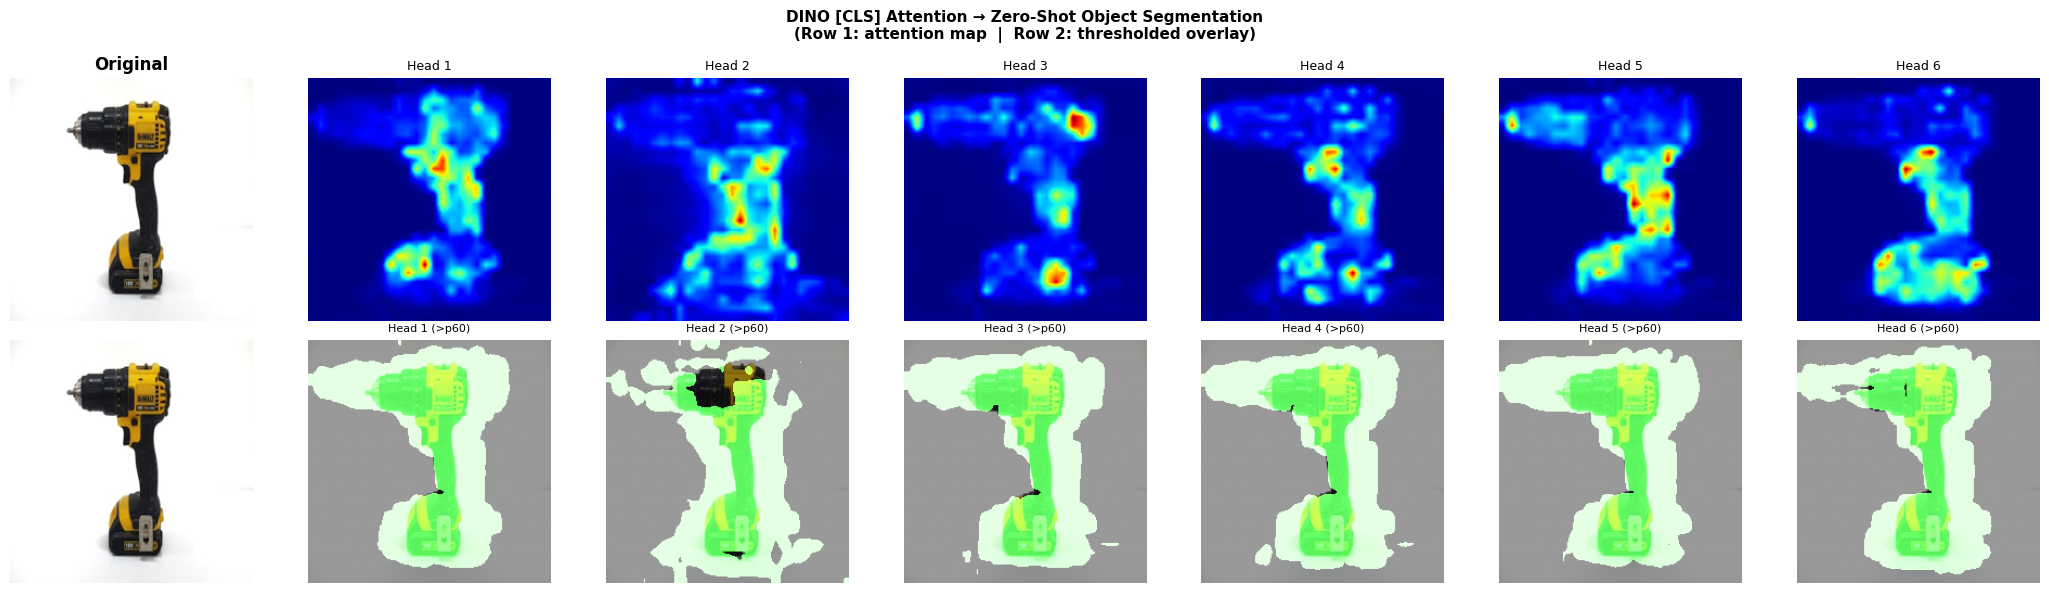

💡 Key insight: No segmentation labels were used to train DINO.
   These attention maps emerge from the self-supervised EMA distillation objective.

--- cooking ---


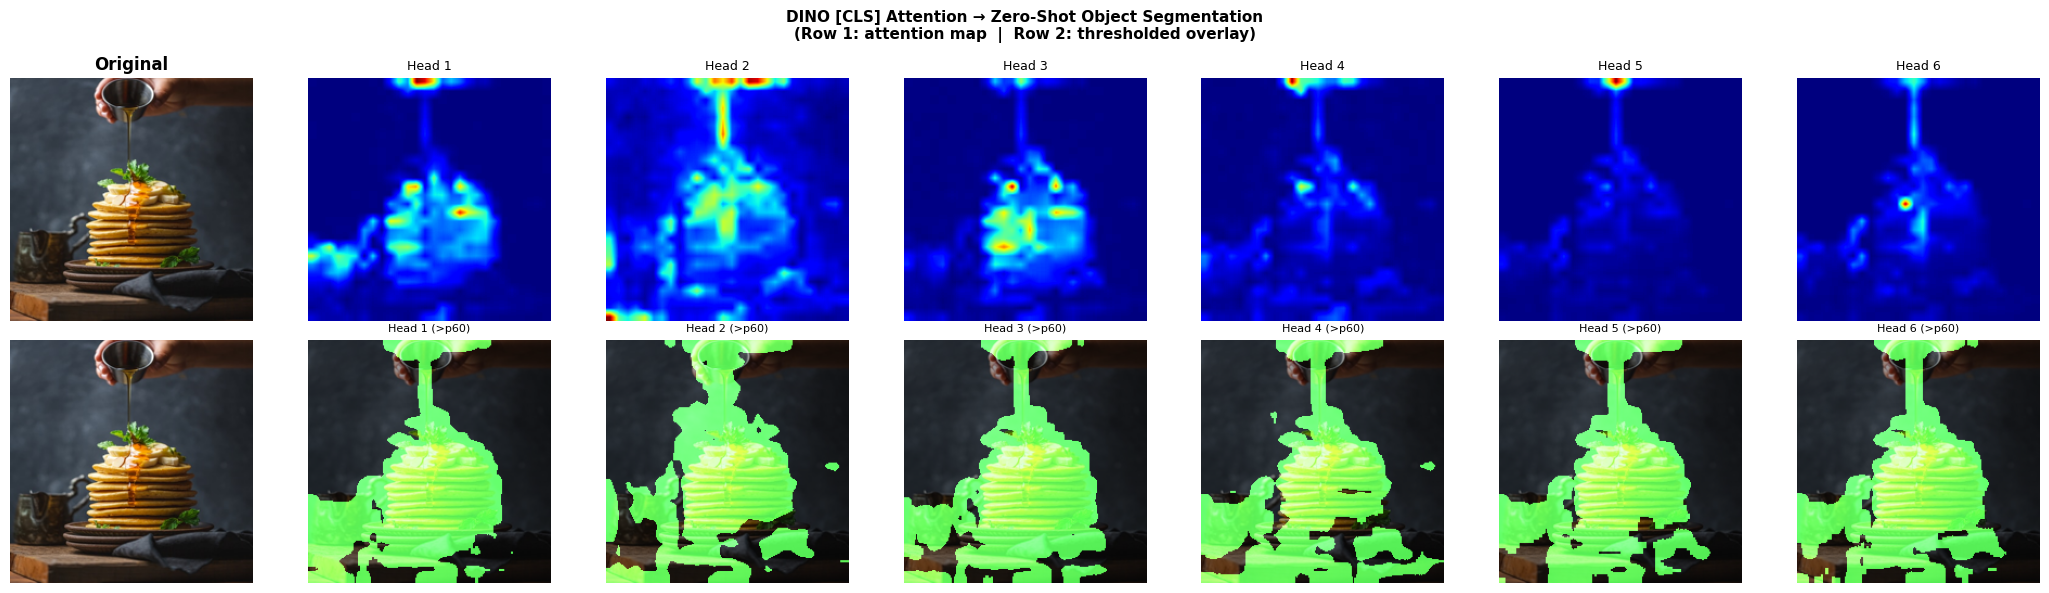

💡 Key insight: No segmentation labels were used to train DINO.
   These attention maps emerge from the self-supervised EMA distillation objective.


In [12]:
def visualize_dino_attention(
    img_pil: Image.Image,
    attentions: torch.Tensor,  # [H, N+1, N+1]
    patch_size: int = 8,
    img_size: int = 224,
    threshold_percentile: float = 60.0,
) -> None:
    """
    Visualize DINO attention maps for each head.

    The [CLS] token's attention to patch tokens (attentions[:, 0, 1:]) gives
    a spatial map that — remarkably — segments foreground objects.

    [CLS] = index 0 in the N+1 sequence
    Patches = indices 1: in the N+1 sequence
    """
    n_heads = attentions.shape[0]
    grid_size = img_size // patch_size  # 28

    # CLS attending to patch tokens: attentions[:, 0, 1:]
    # YOUR TURN: extract [CLS] → patch attention for each head
    # ------ SOLUTION ------
    cls_to_patch = attentions[:, 0, 1:]  # [H, N_patches]
    # ----------------------

    fig, axes = plt.subplots(2, n_heads + 1, figsize=(3*(n_heads+1), 6))

    # Original image
    img_np = np.array(img_pil.resize((img_size, img_size)))
    axes[0, 0].imshow(img_np); axes[0, 0].set_title('Original', fontweight='bold')
    axes[1, 0].imshow(img_np); axes[1, 0].axis('off')
    axes[0, 0].axis('off')

    # Mean attention over all heads
    mean_attn = cls_to_patch.mean(0).reshape(grid_size, grid_size).numpy()  # [28, 28]
    mean_attn = (mean_attn - mean_attn.min()) / (mean_attn.max() - mean_attn.min() + 1e-8)

    for h in range(n_heads):
        attn_map = cls_to_patch[h].reshape(grid_size, grid_size).numpy()  # [28, 28]
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

        # Resize to image resolution for overlay
        from PIL import Image as PILImage
        attn_img = PILImage.fromarray((attn_map * 255).astype(np.uint8))
        attn_img = np.array(attn_img.resize((img_size, img_size), PILImage.BILINEAR)) / 255.0

        # Threshold: keep top percentile
        thresh = np.percentile(attn_img, threshold_percentile)
        binary_mask = attn_img > thresh

        axes[0, h+1].imshow(attn_img, cmap='jet', vmin=0, vmax=1)
        axes[0, h+1].set_title(f'Head {h+1}', fontsize=9)
        axes[0, h+1].axis('off')

        # Overlay on image
        overlay = img_np.copy().astype(float) / 255
        mask_rgb = np.stack([binary_mask * 0.3, binary_mask * 0.9, binary_mask * 0.3], axis=-1)
        overlay = np.clip(overlay * 0.6 + mask_rgb, 0, 1)
        axes[1, h+1].imshow(overlay)
        axes[1, h+1].set_title(f'Head {h+1} (>p{int(threshold_percentile)})', fontsize=8)
        axes[1, h+1].axis('off')

    plt.suptitle('DINO [CLS] Attention → Zero-Shot Object Segmentation\n(Row 1: attention map  |  Row 2: thresholded overlay)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("💡 Key insight: No segmentation labels were used to train DINO.")
    print("   These attention maps emerge from the self-supervised EMA distillation objective.")


# Visualize for each sample image
for name, img_tensor in tensor_images.items():
    print(f"\n--- {name} ---")
    feats = extract_dino_features(dino_model, img_tensor, return_attentions=True)
    if 'attentions' in feats:
        visualize_dino_attention(pil_images[name], feats['attentions'])

> **❓ Question 1**: Why do different attention heads specialize in different object parts? What aspect of the training objective (EMA teacher-student, no explicit supervision) would encourage this head specialization?

---
## Part 4 — Feature Properties: Semantic Consistency

Before building the world model, we verify that DINO features have the semantic consistency property we need: similar states → similar embeddings.

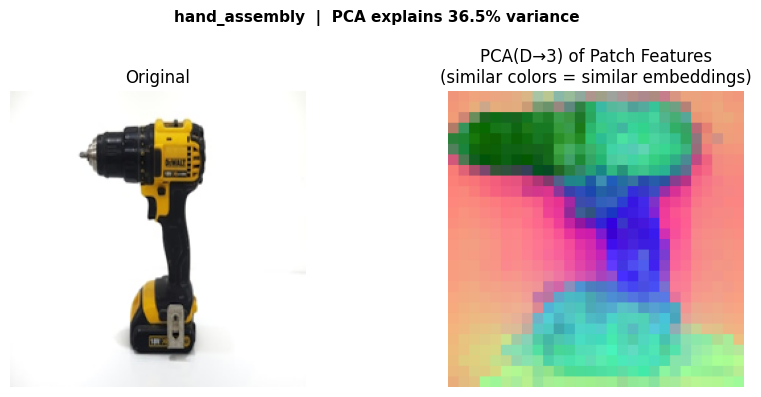

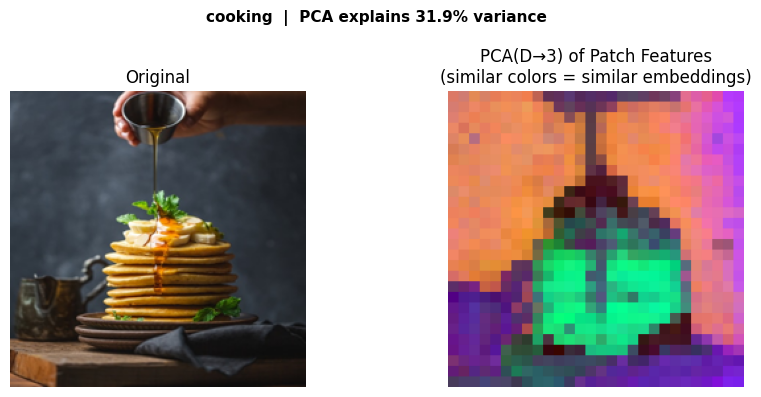

In [13]:
# Verify spatial semantic structure: reshape patch tokens to 2D grid and visualize via PCA
from sklearn.decomposition import PCA

@torch.no_grad()
def visualize_feature_pca(
    img_pil: Image.Image,
    patch_tokens: torch.Tensor,  # [N, D]
    grid_size: int = 28,
    title: str = '',
) -> None:
    """
    Project patch embeddings to 3D via PCA and visualize as RGB image.
    Semantically similar patches will have similar colors.
    This reveals the spatial semantic structure in the features.
    """
    Z = patch_tokens.numpy()  # [N, D]

    pca = PCA(n_components=3)
    Z_pca = pca.fit_transform(Z)  # [N, 3]

    # Normalize each PCA component to [0, 1] for RGB display
    Z_rgb = Z_pca - Z_pca.min(0)  # shift to positive
    Z_rgb = Z_rgb / (Z_rgb.max(0) + 1e-8)  # normalize to [0,1]
    Z_rgb = Z_rgb.reshape(grid_size, grid_size, 3)  # [28, 28, 3]

    # Upsample to full image resolution
    from PIL import Image as PILImage
    pca_img = PILImage.fromarray((Z_rgb * 255).astype(np.uint8))
    pca_img = pca_img.resize((224, 224), PILImage.NEAREST)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img_pil.resize((224, 224)))
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(pca_img)
    axes[1].set_title(f'PCA(D→3) of Patch Features\n(similar colors = similar embeddings)')
    axes[1].axis('off')

    explained = pca.explained_variance_ratio_[:3].sum() * 100
    plt.suptitle(f'{title}  |  PCA explains {explained:.1f}% variance', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

for name, img_tensor in tensor_images.items():
    feats = extract_dino_features(dino_model, img_tensor)
    visualize_feature_pca(pil_images[name], feats['patch_tokens'], title=name)

---
## Part 5 — Synthetic Environment for World Model Training

We create a minimal simulation environment to train and test the dynamics model.  
The environment models a simple 2D ball that can be pushed in 4 directions —  
enough to demonstrate the planning loop without requiring real robot data.

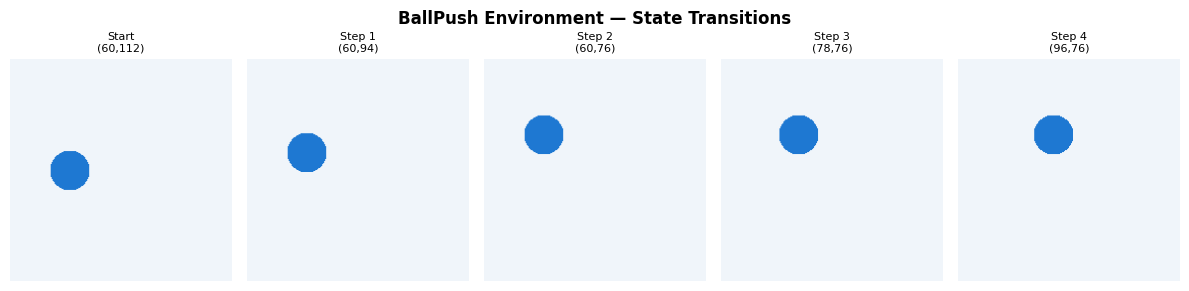

✓ Environment working correctly


In [14]:
class BallPushEnvironment:
    """
    Minimal 2D ball-pushing environment.

    State: position of a ball on a 224x224 canvas
    Action: 4-dimensional one-hot [up, down, left, right], each moves ball by step_size

    This is a proxy for robot end-effector control in DINO-WM.
    In the actual project, replace with IndEgo video frame sequences + recorded actions.
    """

    ACTION_DIM = 4
    IMG_SIZE   = 224
    BALL_RADIUS = 20
    STEP_SIZE   = 18  # pixels per action
    BG_COLOR    = (240, 245, 250)   # light blue-grey
    BALL_COLOR  = (30, 120, 210)    # blue
    GOAL_COLOR  = (20, 190, 80)     # green goal marker

    def __init__(self, seed: int = 42):
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self, pos: np.ndarray | None = None) -> np.ndarray:
        margin = self.BALL_RADIUS + 5
        if pos is None:
            self.ball_pos = self.rng.integers(
                margin, self.IMG_SIZE - margin, size=2
            ).astype(float)
        else:
            self.ball_pos = pos.copy()
        return self.ball_pos.copy()

    def step(self, action: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Apply action (4-d one-hot), return (new_pos, obs_image)."""
        action_idx = np.argmax(action)
        deltas = {0: (-self.STEP_SIZE, 0), 1: (self.STEP_SIZE, 0),
                  2: (0, -self.STEP_SIZE), 3: (0, self.STEP_SIZE)}
        dy, dx = deltas[action_idx]
        self.ball_pos[0] = np.clip(self.ball_pos[0] + dx, self.BALL_RADIUS, self.IMG_SIZE - self.BALL_RADIUS)
        self.ball_pos[1] = np.clip(self.ball_pos[1] + dy, self.BALL_RADIUS, self.IMG_SIZE - self.BALL_RADIUS)
        return self.ball_pos.copy(), self.render()

    def render(self, goal_pos: np.ndarray | None = None) -> Image.Image:
        """Render current state as PIL image."""
        canvas = np.full((self.IMG_SIZE, self.IMG_SIZE, 3), self.BG_COLOR, dtype=np.uint8)

        # Draw goal circle if provided
        if goal_pos is not None:
            gx, gy = int(goal_pos[0]), int(goal_pos[1])
            for py in range(max(0, gy-self.BALL_RADIUS), min(self.IMG_SIZE, gy+self.BALL_RADIUS)):
                for px in range(max(0, gx-self.BALL_RADIUS), min(self.IMG_SIZE, gx+self.BALL_RADIUS)):
                    if (px-gx)**2 + (py-gy)**2 < self.BALL_RADIUS**2:
                        canvas[py, px] = self.GOAL_COLOR

        # Draw ball
        bx, by = int(self.ball_pos[0]), int(self.ball_pos[1])
        for py in range(max(0, by-self.BALL_RADIUS), min(self.IMG_SIZE, by+self.BALL_RADIUS)):
            for px in range(max(0, bx-self.BALL_RADIUS), min(self.IMG_SIZE, bx+self.BALL_RADIUS)):
                if (px-bx)**2 + (py-by)**2 < self.BALL_RADIUS**2:
                    canvas[py, px] = self.BALL_COLOR

        return Image.fromarray(canvas)


# Test the environment
env = BallPushEnvironment(seed=42)
start_pos = env.reset(pos=np.array([60.0, 112.0]))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(env.render())
axes[0].set_title(f'Start\n({int(start_pos[0])},{int(start_pos[1])})', fontsize=8)
axes[0].axis('off')

actions_demo = [[1,0,0,0], [1,0,0,0], [0,0,0,1], [0,0,0,1]]  # right, right, down, down
for i, act in enumerate(actions_demo):
    pos, img = env.step(np.array(act))
    axes[i+1].imshow(img)
    axes[i+1].set_title(f'Step {i+1}\n({int(pos[0])},{int(pos[1])})', fontsize=8)
    axes[i+1].axis('off')

plt.suptitle('BallPush Environment — State Transitions', fontweight='bold')
plt.tight_layout()
plt.show()
print('✓ Environment working correctly')

---
## Part 6 — Collect Training Data

We generate a small dataset of $(z_t, a_t, z_{t+1})$ triples by running random trajectories in the environment and extracting DINO features from each frame.

In [15]:
@torch.no_grad()
def image_to_dino_features(img_pil: Image.Image) -> torch.Tensor:
    """PIL image → L2-normalized DINO patch features [N, D]."""
    tensor = transform(img_pil).unsqueeze(0).to(DEVICE)
    out = dino_model.forward_features(tensor)  # [1, N+1, D]
    patches = F.normalize(out[0, 1:, :], dim=-1)  # [N, D]
    return patches.cpu()


def collect_dataset(
    n_trajectories: int = 80,
    trajectory_length: int = 12,
    seed: int = 0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Collect (z_t, a_t, z_{t+1}) triples.

    Returns
    -------
    Z_t    : [M, N_patches, D]
    A_t    : [M, ACTION_DIM]
    Z_tp1  : [M, N_patches, D]  ← STOP-GRADIENT target (already detached)
    """
    data_env = BallPushEnvironment(seed=seed)
    rng = np.random.default_rng(seed)

    Z_t_list, A_t_list, Z_tp1_list = [], [], []

    for traj in trange(n_trajectories, desc='Collecting data'):
        data_env.reset()
        img_t = data_env.render()
        z_t = image_to_dino_features(img_t)  # [N, D]

        for _ in range(trajectory_length):
            # Random action
            action_idx = rng.integers(0, BallPushEnvironment.ACTION_DIM)
            a_t = np.zeros(BallPushEnvironment.ACTION_DIM)
            a_t[action_idx] = 1.0

            _, img_tp1 = data_env.step(a_t)
            z_tp1 = image_to_dino_features(img_tp1)

            Z_t_list.append(z_t)
            A_t_list.append(torch.from_numpy(a_t).float())
            Z_tp1_list.append(z_tp1)

            z_t = z_tp1  # advance state
            img_t = img_tp1

    return (
        torch.stack(Z_t_list),      # [M, 784, 384]
        torch.stack(A_t_list),      # [M, 4]
        torch.stack(Z_tp1_list),    # [M, 784, 384]  — targets (stop-grad applied at loss time)
    )


print("Collecting training data (this may take 2-5 minutes on CPU)...")
Z_t, A_t, Z_tp1 = collect_dataset(n_trajectories=60, trajectory_length=10)

print(f'\nDataset statistics:')
print(f'  Transitions:   {Z_t.shape[0]:,}')
print(f'  Z_t shape:     {list(Z_t.shape)}')
print(f'  A_t shape:     {list(A_t.shape)}')
print(f'  Z_tp1 shape:   {list(Z_tp1.shape)}')
print(f'  Storage:       {Z_t.nbytes/1e6:.1f} MB')


Dataset statistics:
  Transitions:   600
  Z_t shape:     [600, 784, 384]
  A_t shape:     [600, 4]
  Z_tp1 shape:   [600, 784, 384]
  Storage:       722.5 MB


---
## Part 7 — Task 2: Implement the Dynamics Model

The dynamics model $f_\theta(z_t, a_t)$ predicts the next-frame features.  
Key design choices:
1. **Residual prediction**: predict $\Delta z = z_{t+1} - z_t$ rather than $z_{t+1}$ directly
2. **Per-patch independence**: each patch MLP is identical (weight sharing) and operates independently
3. **Stop-gradient target**: `z_{t+1}.detach()` — NO gradient flows to the frozen DINO encoder

In [16]:
class DynamicsMLP(nn.Module):
    """
    Per-patch MLP dynamics model.

    For each patch token z_i^t ∈ ℝ^D:
        Δz_i = MLP([z_i^t | a_t])
        ẑ_i^{t+1} = normalize(z_i^t + Δz_i)

    Weight sharing across all N patches (same MLP applied independently).
    Action a_t is broadcast to every patch via concatenation.

    Parameters
    ----------
    embed_dim  : DINO feature dimension (384 for ViT-S)
    action_dim : Number of discrete actions (4)
    hidden_dim : MLP hidden width
    n_layers   : MLP depth
    """

    def __init__(
        self,
        embed_dim: int = 384,
        action_dim: int = 4,
        hidden_dim: int = 256,
        n_layers: int = 3,
    ):
        super().__init__()
        self.embed_dim  = embed_dim
        self.action_dim = action_dim

        in_dim = embed_dim + action_dim
        layers = []
        for i in range(n_layers):
            layers.append(nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim))
            layers.append(nn.GELU())
            layers.append(nn.LayerNorm(hidden_dim))
        layers.append(nn.Linear(hidden_dim, embed_dim))
        self.mlp = nn.Sequential(*layers)

        # Initialize final layer to zero → initial predictions = identity (z_t → z_t)
        # This ensures stable early training: model starts as a no-op and learns perturbations
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.zeros_(self.mlp[-1].bias)

    def forward(
        self,
        z_t: torch.Tensor,   # [B, N, D]
        a_t: torch.Tensor,   # [B, A]
    ) -> torch.Tensor:
        """
        Predict next-step features.

        YOUR TURN: implement the forward pass
        Steps:
        1. Broadcast action to all patches: a_t [B, A] → [B, N, A]
        2. Concatenate z_t and action: [B, N, D+A]
        3. Apply MLP to compute residual Δz: [B, N, D]
        4. Add residual and L2-normalize: z_{t+1} = normalize(z_t + Δz)
        """
        # ------ SOLUTION (remove before distributing to students) ------
        B, N, D = z_t.shape

        # 1. Broadcast action to all patches
        a_expanded = a_t.unsqueeze(1).expand(B, N, -1)  # [B, N, A]

        # 2. Concatenate features and action
        x = torch.cat([z_t, a_expanded], dim=-1)  # [B, N, D+A]

        # 3. Apply shared MLP to compute residual
        delta_z = self.mlp(x)  # [B, N, D]

        # 4. Residual connection + L2 normalize
        z_next = F.normalize(z_t + delta_z, dim=-1)  # [B, N, D]
        return z_next
        # ---------------------------------------------------------------


# Instantiate and verify
dynamics = DynamicsMLP(
    embed_dim=EMBED_DIM,
    action_dim=BallPushEnvironment.ACTION_DIM,
    hidden_dim=256,
    n_layers=3,
).to(DEVICE)

n_params = sum(p.numel() for p in dynamics.parameters())
print(f'Dynamics model parameters: {n_params/1e3:.1f}K  (compare: DINO = {sum(p.numel() for p in dino_model.parameters())/1e6:.1f}M)')
print(f'Dynamics = {n_params / sum(p.numel() for p in dino_model.parameters()) * 100:.2f}% of DINO size')

# Verify forward pass
dummy_z = torch.randn(4, N_PATCHES, EMBED_DIM).to(DEVICE)
dummy_z = F.normalize(dummy_z, dim=-1)
dummy_a = torch.zeros(4, BallPushEnvironment.ACTION_DIM).to(DEVICE)
dummy_a[:, 0] = 1.0  # all "up"

with torch.no_grad():
    z_pred = dynamics(dummy_z, dummy_a)

print(f'\nForward pass: z_t {list(dummy_z.shape)} → z_tp1 {list(z_pred.shape)}')
print(f'Output L2 norms (should be ~1.0): {z_pred.norm(dim=-1).mean().item():.4f}')
# Initially the model is near-identity:
initial_sim = (dummy_z * z_pred).sum(-1).mean().item()
print(f'Initial self-similarity (should be ~1.0): {initial_sim:.4f}')

Dynamics model parameters: 331.4K  (compare: DINO = 21.7M)
Dynamics = 1.53% of DINO size

Forward pass: z_t [4, 784, 384] → z_tp1 [4, 784, 384]
Output L2 norms (should be ~1.0): 1.0000
Initial self-similarity (should be ~1.0): 1.0000


---
## Part 8 — Train the Dynamics Model

Training dynamics model: 600 transitions, 30 epochs
Batch size: 256  |  Steps/epoch: 3


Training: 100%|██████████| 30/30 [01:29<00:00,  2.98s/it]


Final: loss=0.000154  cos_sim=0.9704


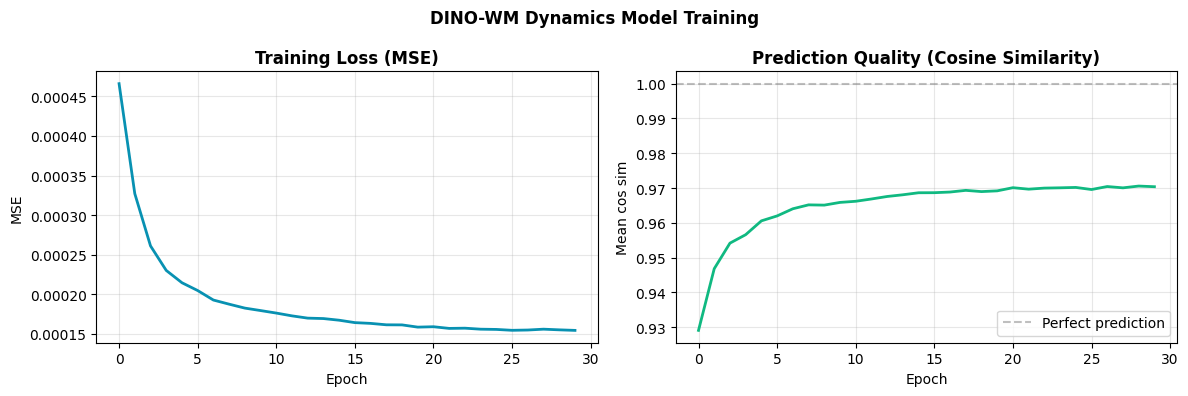

In [17]:
from torch.utils.data import TensorDataset, DataLoader

# DataLoader
dataset = TensorDataset(Z_t, A_t, Z_tp1)
loader  = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=0)

# Optimizer
optimizer = torch.optim.AdamW(
    dynamics.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

def compute_loss(
    z_pred: torch.Tensor,   # [B, N, D] — predicted next features
    z_target: torch.Tensor, # [B, N, D] — actual next features
) -> torch.Tensor:
    """
    JEPA-style loss: MSE in normalized embedding space.

    CRITICAL: z_target must be detached (stop-gradient).
    The frozen DINO encoder provides stable targets — no gradient should flow through it.

    We compute the loss per-patch then average: L = (1/N) Σᵢ ||ẑᵢ - sg(zᵢ)||²
    """
    # ------ SOLUTION ------
    target = z_target.detach()  # ← stop-gradient: this is the critical line
    return F.mse_loss(z_pred, target)
    # ----------------------


# Training loop
N_EPOCHS = 30
train_losses, val_sims = [], []

print(f'Training dynamics model: {len(dataset):,} transitions, {N_EPOCHS} epochs')
print(f'Batch size: 256  |  Steps/epoch: {len(loader)}')

for epoch in trange(N_EPOCHS, desc='Training'):
    dynamics.train()
    epoch_loss = 0.0

    for z_t_batch, a_t_batch, z_tp1_batch in loader:
        z_t_batch   = z_t_batch.to(DEVICE)
        a_t_batch   = a_t_batch.to(DEVICE)
        z_tp1_batch = z_tp1_batch.to(DEVICE)

        z_pred = dynamics(z_t_batch, a_t_batch)
        loss = compute_loss(z_pred, z_tp1_batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dynamics.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)

    # Validation: mean cosine similarity between predicted and actual features
    dynamics.eval()
    with torch.no_grad():
        idx = torch.randint(0, len(Z_t), (512,))
        z_v  = Z_t[idx].to(DEVICE)
        a_v  = A_t[idx].to(DEVICE)
        zt1_v = Z_tp1[idx].to(DEVICE)
        zp_v  = dynamics(z_v, a_v)
        cos_sim = (zp_v * zt1_v).sum(-1).mean().item()
    val_sims.append(cos_sim)

print(f'\nFinal: loss={train_losses[-1]:.6f}  cos_sim={val_sims[-1]:.4f}')

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='#0891B2', linewidth=2)
axes[0].set_title('Training Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].grid(alpha=0.3)

axes[1].plot(val_sims, color='#10B981', linewidth=2)
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect prediction')
axes[1].set_title('Prediction Quality (Cosine Similarity)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean cos sim'); axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle('DINO-WM Dynamics Model Training', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 9 — Task 3: Receding-Horizon Planning Loop

The trained world model enables **model-based planning without any policy training**.  
We use **random shooting** (the simplest MPC method): sample random action sequences, simulate them with $f_\theta$, score vs. goal.

In [18]:
@torch.no_grad()
def goal_similarity(
    z_pred: torch.Tensor,   # [B, N, D] — predicted state embedding
    z_goal: torch.Tensor,   # [1, N, D] — goal state embedding
) -> torch.Tensor:
    """
    Score how close a predicted state is to the goal in DINO feature space.

    We use mean patch-level cosine similarity as the reward signal.
    Returns [B] scores (higher = closer to goal).

    YOUR TURN: implement this
    Hint: element-wise product, sum over D, mean over N
    """
    # ------ SOLUTION ------
    # Both are L2-normalized: dot product = cosine similarity
    # z_pred: [B, N, D],  z_goal: [1, N, D]  → broadcast over B
    sim = (z_pred * z_goal).sum(dim=-1)  # [B, N]
    return sim.mean(dim=-1)              # [B]
    # ----------------------


@torch.no_grad()
def random_shooting_plan(
    dynamics_model: nn.Module,
    z_current: torch.Tensor,  # [1, N, D] — current state embedding
    z_goal:    torch.Tensor,  # [1, N, D] — goal state embedding
    horizon: int = 5,
    n_samples: int = 200,
    action_dim: int = 4,
) -> np.ndarray:
    """
    Random-shooting MPC:
    1. Sample n_samples random action sequences of length `horizon`
    2. Roll out dynamics model for each sequence
    3. Score final state against goal
    4. Return the FIRST action of the best-scoring sequence

    This is the simplest possible MPC — no gradient through dynamics, no CEM.
    The DINO-WM paper uses Cross-Entropy Method (CEM) for better planning.
    """
    dynamics_model.eval()

    # YOUR TURN: implement steps 1-4
    # Hint: broadcast z_current to [n_samples, N, D], then apply dynamics model in a loop
    # ------ SOLUTION ------
    # 1. Sample random action sequences
    action_seqs = torch.zeros(n_samples, horizon, action_dim)
    action_indices = torch.randint(0, action_dim, (n_samples, horizon))
    for b in range(n_samples):
        for t in range(horizon):
            action_seqs[b, t, action_indices[b, t]] = 1.0
    action_seqs = action_seqs.to(DEVICE)

    # 2. Roll out dynamics model
    z_curr_batch = z_current.expand(n_samples, -1, -1).clone()  # [n_samples, N, D]

    for t in range(horizon):
        a_t = action_seqs[:, t, :]  # [n_samples, A]
        z_curr_batch = dynamics_model(z_curr_batch, a_t)  # [n_samples, N, D]

    # 3. Score final states
    scores = goal_similarity(z_curr_batch, z_goal.expand(n_samples, -1, -1))  # [n_samples]

    # 4. Best first action
    best_seq_idx = scores.argmax().item()
    best_first_action = action_seqs[best_seq_idx, 0, :].cpu().numpy()
    return best_first_action
    # ---------------------------------------------------------------


print('Planning functions defined. Running a planning episode...')

Planning functions defined. Running a planning episode...


  ✓ Goal reached at step 6! Distance = 16.0px
Final distance: 16.0px  |  Steps taken: 7


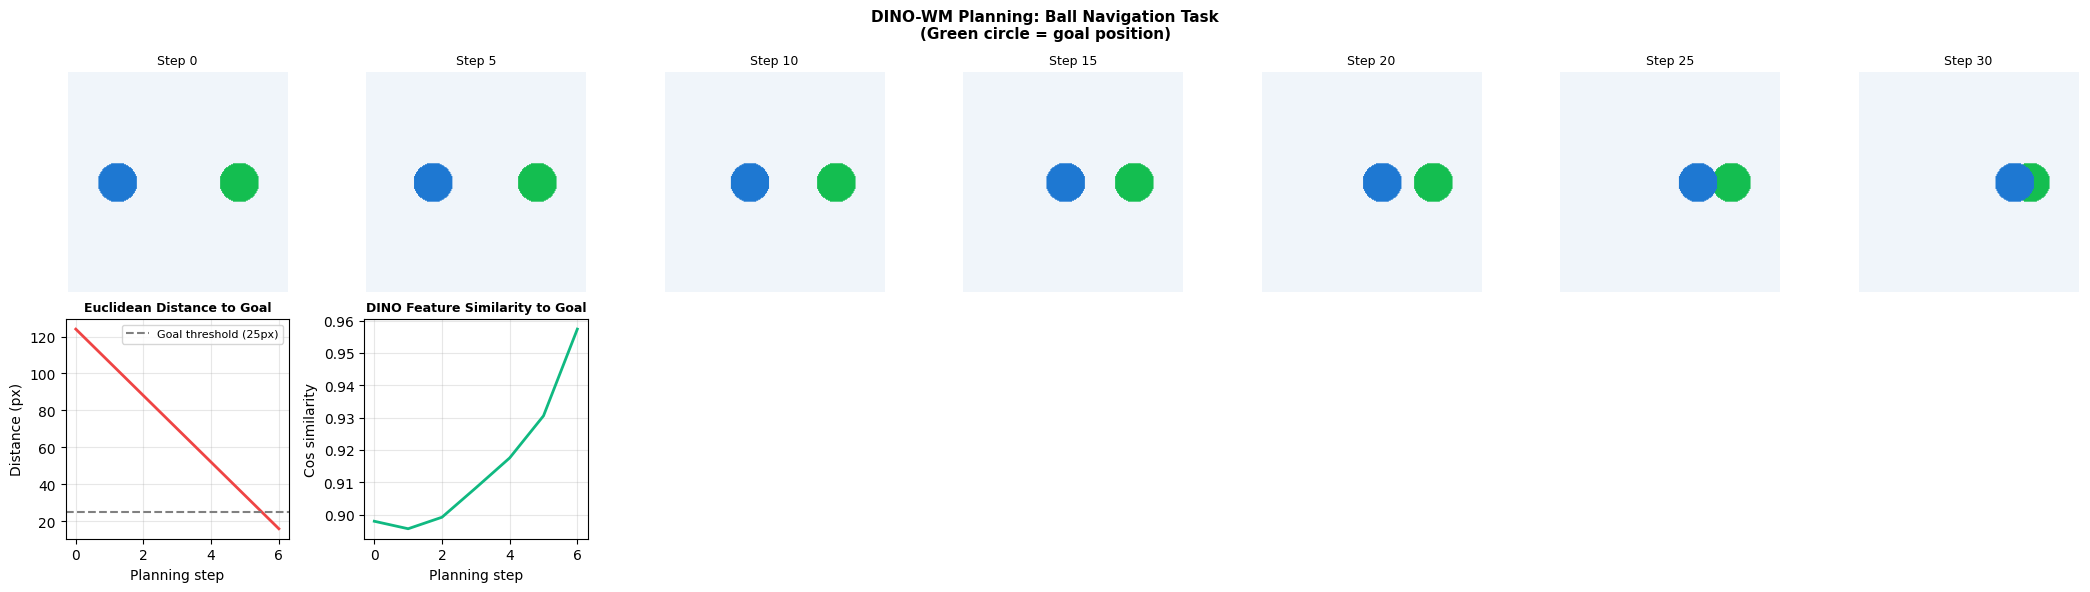

In [19]:
# Full planning episode: navigate ball to goal position

env_plan = BallPushEnvironment(seed=100)
start_pos = np.array([50.0, 112.0])
goal_pos  = np.array([174.0, 112.0])

env_plan.reset(pos=start_pos)

# Compute goal embedding (ground truth image at goal position)
env_goal = BallPushEnvironment(seed=999)
env_goal.reset(pos=goal_pos)
goal_img = env_goal.render()
z_goal = image_to_dino_features(goal_img).unsqueeze(0).to(DEVICE)  # [1, N, D]

# Planning loop
MAX_STEPS = 25
TOLERANCE = 25  # pixels

trajectory_imgs = [env_plan.render(goal_pos=goal_pos)]
distances, step_scores = [], []

dynamics.eval()
for step in range(MAX_STEPS):
    # Current state
    curr_img = env_plan.render()
    z_curr = image_to_dino_features(curr_img).unsqueeze(0).to(DEVICE)

    # Feature-space similarity to goal
    score = goal_similarity(z_curr, z_goal).item()
    step_scores.append(score)

    # Euclidean distance (for evaluation only — NOT used by planner)
    dist = np.linalg.norm(env_plan.ball_pos - goal_pos)
    distances.append(dist)

    if dist < TOLERANCE:
        print(f'  ✓ Goal reached at step {step}! Distance = {dist:.1f}px')
        break

    # Plan: select best action
    best_action = random_shooting_plan(
        dynamics, z_curr, z_goal,
        horizon=6, n_samples=256,
    )

    # Execute action
    env_plan.step(best_action)

    if step % 5 == 0 or step < 5:
        trajectory_imgs.append(env_plan.render(goal_pos=goal_pos))

print(f'Final distance: {distances[-1]:.1f}px  |  Steps taken: {len(distances)}')

# Visualize trajectory
n_show = min(len(trajectory_imgs), 7)
fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))

for i, img in enumerate(trajectory_imgs[:n_show]):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Step {i*5 if i > 0 else 0}', fontsize=9)
    axes[0, i].axis('off')

# Plot distance and score curves
axes[1, 0].plot(distances, color='#EF4444', linewidth=2)
axes[1, 0].axhline(TOLERANCE, color='gray', linestyle='--', label=f'Goal threshold ({TOLERANCE}px)')
axes[1, 0].set_title('Euclidean Distance to Goal', fontsize=9, fontweight='bold')
axes[1, 0].set_xlabel('Planning step'); axes[1, 0].set_ylabel('Distance (px)')
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(step_scores, color='#10B981', linewidth=2)
axes[1, 1].set_title('DINO Feature Similarity to Goal', fontsize=9, fontweight='bold')
axes[1, 1].set_xlabel('Planning step'); axes[1, 1].set_ylabel('Cos similarity')
axes[1, 1].grid(alpha=0.3)

for i in range(2, n_show):
    axes[1, i].axis('off')

plt.suptitle('DINO-WM Planning: Ball Navigation Task\n(Green circle = goal position)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

> **❓ Question 2**: The planner uses DINO feature similarity as the reward — not Euclidean pixel distance. What are the advantages of this approach for real-world manipulation tasks (e.g., in the IndEgo dataset)?

---
## Part 10 — BONUS: Multi-Step Prediction Rollout & Error Accumulation

Evaluating multi-step prediction quality...


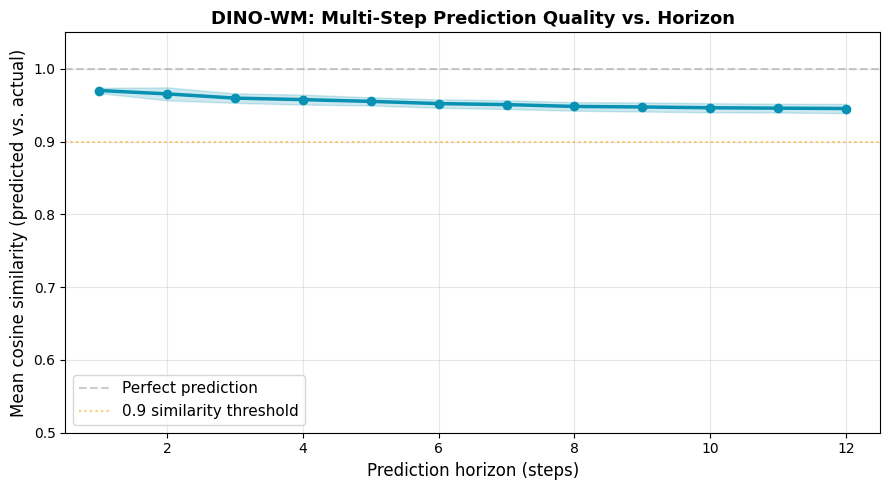


Prediction quality at each horizon step:
  h= 1  [███████████████████░]  0.9701 ± 0.0036
  h= 2  [███████████████████░]  0.9654 ± 0.0089
  h= 3  [███████████████████░]  0.9596 ± 0.0065
  h= 4  [███████████████████░]  0.9576 ± 0.0068
  h= 5  [███████████████████░]  0.9551 ± 0.0056
  h= 6  [███████████████████░]  0.9521 ± 0.0058
  h= 7  [███████████████████░]  0.9507 ± 0.0060
  h= 8  [██████████████████░░]  0.9482 ± 0.0059
  h= 9  [██████████████████░░]  0.9475 ± 0.0063
  h=10  [██████████████████░░]  0.9464 ± 0.0063
  h=11  [██████████████████░░]  0.9459 ± 0.0060
  h=12  [██████████████████░░]  0.9453 ± 0.0064


In [20]:
# Evaluate how prediction error accumulates over multiple steps
# This is a critical diagnostic for world model quality

@torch.no_grad()
def evaluate_rollout_quality(
    dynamics_model: nn.Module,
    n_rollouts: int = 50,
    max_horizon: int = 15,
) -> np.ndarray:
    """
    Evaluate mean cosine similarity between predicted and actual features
    as horizon increases. Returns [max_horizon] similarity scores.
    """
    dynamics_model.eval()
    eval_env = BallPushEnvironment(seed=9999)
    rng = np.random.default_rng(9999)

    horizon_sims = np.zeros((n_rollouts, max_horizon))

    for trial in range(n_rollouts):
        eval_env.reset()
        img = eval_env.render()
        z_curr = image_to_dino_features(img).unsqueeze(0).to(DEVICE)  # [1, N, D]

        for h in range(max_horizon):
            # Random action
            a = np.zeros(BallPushEnvironment.ACTION_DIM)
            a[rng.integers(0, BallPushEnvironment.ACTION_DIM)] = 1.0
            a_tensor = torch.from_numpy(a).float().unsqueeze(0).to(DEVICE)  # [1, A]

            # Predicted next state
            z_pred = dynamics_model(z_curr, a_tensor)  # [1, N, D]

            # Actual next state
            _, img_next = eval_env.step(a)
            z_actual = image_to_dino_features(img_next).unsqueeze(0).to(DEVICE)  # [1, N, D]

            sim = (z_pred * z_actual).sum(-1).mean().item()
            horizon_sims[trial, h] = sim

            z_curr = z_pred  # autoregressive rollout

    return horizon_sims.mean(0), horizon_sims.std(0)


print('Evaluating multi-step prediction quality...')
mean_sims, std_sims = evaluate_rollout_quality(dynamics, n_rollouts=40, max_horizon=12)

fig, ax = plt.subplots(figsize=(9, 5))
steps = np.arange(1, len(mean_sims)+1)
ax.plot(steps, mean_sims, color='#0891B2', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(steps, mean_sims - std_sims, mean_sims + std_sims, alpha=0.2, color='#0891B2')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4, label='Perfect prediction')
ax.axhline(0.9, color='orange', linestyle=':', alpha=0.6, label='0.9 similarity threshold')
ax.set_xlabel('Prediction horizon (steps)', fontsize=12)
ax.set_ylabel('Mean cosine similarity (predicted vs. actual)', fontsize=12)
ax.set_title('DINO-WM: Multi-Step Prediction Quality vs. Horizon', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.05)
ax.set_xlim(0.5, len(mean_sims)+0.5)
plt.tight_layout()
plt.show()

print(f'\nPrediction quality at each horizon step:')
for h, (m, s) in enumerate(zip(mean_sims, std_sims)):
    bar = '█' * int(m * 20) + '░' * (20 - int(m * 20))
    print(f'  h={h+1:2d}  [{bar}]  {m:.4f} ± {s:.4f}')

---
## 🏁 Summary & Project Connections

| Workshop task | What you learned | Project connection |
|---|---|---|
| DINO feature extraction | L2-normalized patch embeddings from frozen ViT | State representation for Tasks 3 & 4 |
| Attention visualization | Zero-shot segmentation via [CLS] attention | Interpretability & egocentric scene parsing |
| PCA feature visualization | Spatial semantic organization of features | Validating cross-view alignment (Task 3) |
| Dynamics model | Residual MLP on frozen features | **Task 4: DINO-WM baseline for benchmarking** |
| Planning loop | Feature-space receding-horizon MPC | Imitation learning & robot adaptation (Task 3) |
| Rollout quality | Error accumulation in world model | Key metric for Task 4 comparison |

### Key conceptual takeaways

1. **Decoupling perception from dynamics** enables data-efficient world model learning. The dynamics MLP (∼200K params) learns from hundreds of transitions; a joint model would need orders of magnitude more data.

2. **Stop-gradient is essential**: the dynamics model is trained against `z_{t+1}.detach()` — the frozen DINO encoder, not a jointly-trained target. Without this, the model would collapse.

3. **Feature-space goal specification** is more powerful than pixel-space goals: it abstracts away irrelevant variation (lighting, viewpoint) and focuses on semantic state.

### Next steps before the project sprint
1. Replace the synthetic environment with real IndEgo or Aria dataset frames
2. Upgrade the dynamics model to a Transformer (lets patches attend to each other)
3. Implement **Cross-Entropy Method (CEM)** instead of random shooting for better planning
4. Compare your DINO-WM implementation against VL-JEPA for Task 4 benchmarking

---
*Workshop prepared by Ashwin Nedungadi & NEidl Team | Rostock–Cluj Collaboration | Summer 2026*